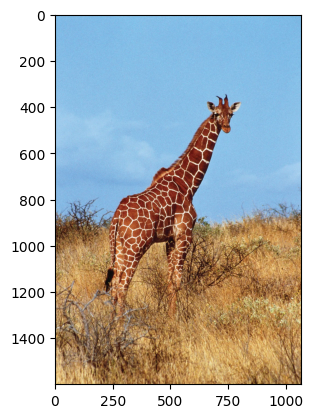

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import cv2

img = cv2.imread('giraffe.png')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)

In [12]:
img.shape

(1600, 1067, 3)

# Perspective transformation

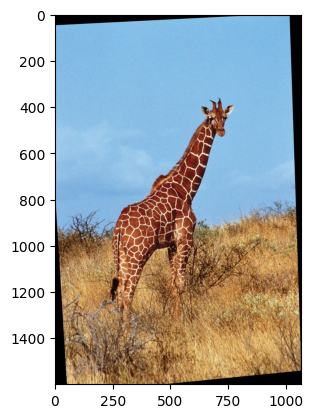

In [13]:
rows, cols, channels = img.shape
input_points = np.float32([[50, 50], [cols-50, 50], [50, rows-50], [cols-50, rows-50]])
output_points = np.float32([[10, 100], [cols-100, 50], [100, rows-10], [cols-50, rows-100]])

M = cv2.getPerspectiveTransform(input_points, output_points)
perspective_img = cv2.warpPerspective(img, M, (cols, rows))
plt.imshow(perspective_img)

In [14]:
print(M)

[[ 1.02287821e+00  6.29847356e-02 -4.42634568e+01]
 [-5.02940991e-02  1.04090741e+00  5.07662367e+01]
 [ 3.13145264e-05  2.80659423e-05  1.00000000e+00]]


# Affine transformation

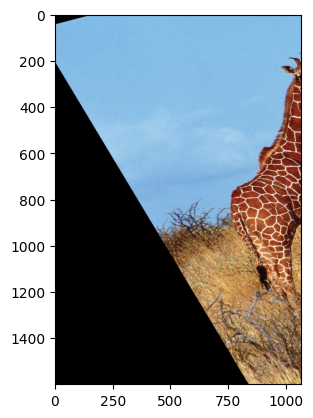

In [16]:
rows, cols, channels = img.shape
input_points = np.float32([[50, 50], [200, 50], [50, 200]])
output_points = np.float32([[10, 100], [200, 50], [100, 250]])

M = cv2.getAffineTransform(input_points, output_points)
affine_img = cv2.warpAffine(img, M, (cols, rows))
plt.imshow(affine_img)

In [17]:
print(M)

[[  1.26666667   0.6        -83.33333333]
 [ -0.33333333   1.          66.66666667]]


# Rotation

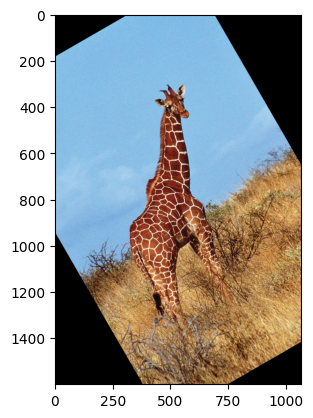

In [21]:
rows, cols, channels = img.shape
angle = 30
center = (cols//2, rows//2)
scale = 1

M = cv2.getRotationMatrix2D(center, angle, scale)
rotated_img = cv2.warpAffine(img, M, (cols, rows))
plt.imshow(rotated_img)

In [22]:
print(M)

[[   0.8660254     0.5        -328.59154022]
 [  -0.5           0.8660254   373.67967697]]


# Shearing

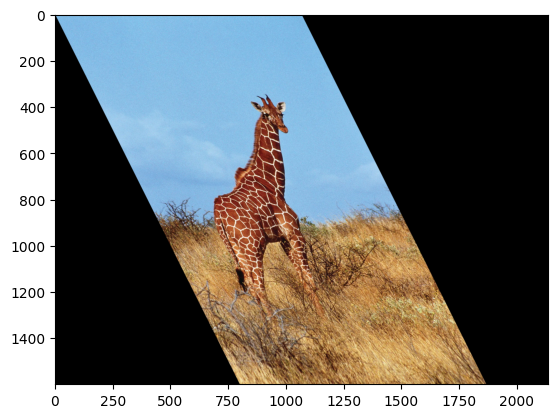

In [24]:
rows, cols, channels = img.shape
shear_x, shear_y = 0.5, 0

M = np.float32([[1, shear_x, 0], [shear_y, 1, 0]])
sheared_img = cv2.warpAffine(img, M, (cols*2, rows))
plt.imshow(sheared_img)

In [25]:
print(M)

[[1.  0.5 0. ]
 [0.  1.  0. ]]


# Translation

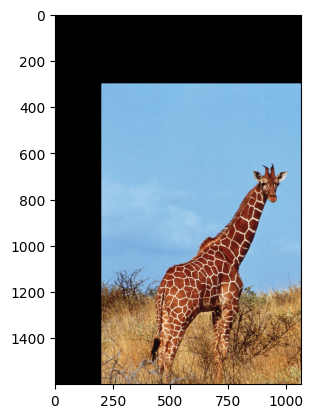

In [26]:
rows, cols, channels = img.shape
tx, ty = 200, 300

M = np.float32([[1, 0, tx], [0, 1, ty]])
translated_img = cv2.warpAffine(img, M, (cols, rows))
plt.imshow(translated_img)

In [27]:
print(M)

[[  1.   0. 200.]
 [  0.   1. 300.]]


# Scaling

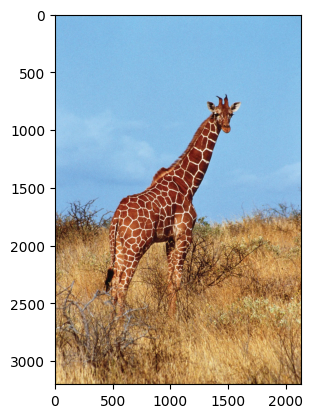

In [29]:
rows, cols, channels = img.shape
scale = 2

M = np.float32([[scale, 0, 0], [0, scale, 0]])
scaled_img = cv2.warpAffine(img, M, (cols*2, rows*2))
plt.imshow(scaled_img)

In [30]:
print(M)

[[2. 0. 0.]
 [0. 2. 0.]]
